In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

IMG_PATH = "/content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-4/dataset/anan.jpg"
BASE_PATH = "/content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-4/results/part-B"

os.makedirs(BASE_PATH, exist_ok=True)

print("Paths ready!")

Paths ready!


In [8]:
#cell No: 2

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    gray = gray.astype(np.float32) / 255.0
    gray = np.expand_dims(gray, axis=-1)  # (H,W,1)
    gray = np.expand_dims(gray, axis=0)   # (1,H,W,1)

    return img, gray

In [9]:
def get_kernels():
    # Edge Detection (Sobel X + Y combined)
    edge = np.array([[-1,  0,  1],
                     [-2,  0,  2],
                     [-1,  0,  1]], dtype=np.float32)

    # Sharpening
    sharpen = np.array([[ 0, -1,  0],
                        [-1,  9, -1],
                        [ 0, -1,  0]], dtype=np.float32)

    # Blurring
    blur = np.array([[1, 2, 1],
                     [2, 4, 2],
                     [1, 2, 1]], dtype=np.float32) / 16.0

    return edge, sharpen, blur

In [10]:
#cell No: 4

def apply_kernel(image, kernel):
    kernel = np.expand_dims(kernel, axis=-1)   # (3,3,1)
    kernel = np.expand_dims(kernel, axis=-1)   # (3,3,1,1)

    kernel_tf = tf.constant(kernel, dtype=tf.float32)

    output = tf.nn.conv2d(
        image,
        filters=kernel_tf,
        strides=1,
        padding='SAME'
    )

    return output.numpy()

In [11]:
#cell No: 5

def plot_and_save(original, edge, sharp, blur):
    fig, axs = plt.subplots(1,4, figsize=(12,4))

    axs[0].imshow(original)
    axs[0].set_title("Original")

    axs[1].imshow(edge[0,:,:,0], cmap='gray')
    axs[1].set_title("Edge")

    axs[2].imshow(sharp[0,:,:,0], cmap='gray')
    axs[2].set_title("Sharpen")

    axs[3].imshow(blur[0,:,:,0], cmap='gray')
    axs[3].set_title("Blur")

    for ax in axs:
        ax.axis("off")

    save_path = f"{BASE_PATH}/kernel_outputs.png"
    plt.savefig(save_path)
    plt.show()

    print("Saved at:", save_path)

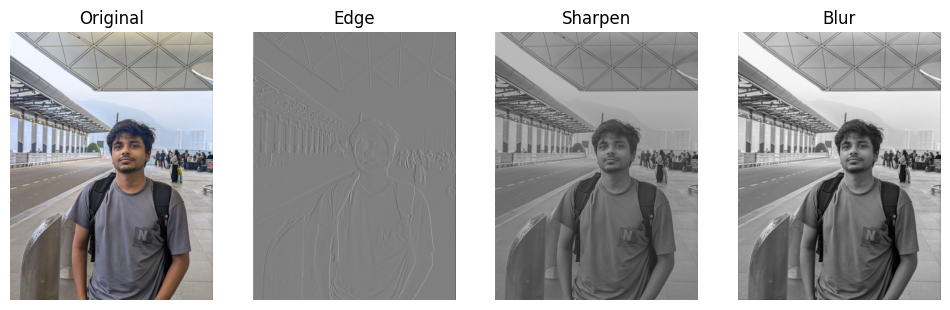

Saved at: /content/drive/MyDrive/4-2/Deep Learning/Assignments/Assignment-4/results/part-B/kernel_outputs.png


In [13]:
#cell No: 6

def main():
    # Load image
    original, gray = load_image(IMG_PATH)

    # Get kernels
    edge, sharpen, blur = get_kernels()

    # Apply kernels
    edge_out = apply_kernel(gray, edge)
    sharp_out = apply_kernel(gray, sharpen)
    blur_out = apply_kernel(gray, blur)

    # Plot + Save
    plot_and_save(original, edge_out, sharp_out, blur_out)


main()